# Tutorial 11. Operations with Saved Data

`pygid` saves the results of conversions and line profiles in a dedicated NeXus (HDF5) format. These files can be reloaded as a `pygid.Conversion` instance for plotting or simulations. Note that since the raw image is no longer available, conversion functions and line profiling will **not** work on the saved file.

Users can:
- Modify selected datasets
- Extract or overwrite experimental or sample metadata
- Inspect the file structure

---

**Step 1: Load the raw data, PONI file, and mask**






In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_11")
    poni_path = files["poni"]
    mask_path = files["mask"]
    # several files for batch processing
    data_path = files["data"]
    smpl_metadata_path = files["smpl_metadata"]
    cif_path = files["cif"]
except:
    print("Dataset download skipped on Read the Docs.")

**Step 2: Convert and save as a NeXus (HDF5) file**

In [2]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True,
)

# add sample metadata
data = {
    "name": "240306_DIP",
    "structure": {
        "stack": "air | DIP 0-25 | SiOx 1 | Si",
        "materials": {
            "DIP": {
                "name": "Diindenoperylene DIP",
                "thickness": 25e-9,     # optional
                "cif": "DIP.cif",       # optional
                "type": "gradient film"
            },
            "SiOx": {
                "name": "native SiOx",
                "thickness": 1
            },
            "Si": {
                "name": "Si wafer"
            }
        }
    },
    "preparation": "gradient thin film prepared by thermal evaporation",
    "experimental_conditions": "standard conditions, on air"
}

smpl_metadata = pygid.SampleMetadata(data=data)

# add experimental metadata
exp_metadata = pygid.ExpMetadata(
    start_time="2024-03-29T15:51:41.343788",
    end_time="2024-07-12T08:26:22Z",
    source_type="synchrotron",
    source_name="ESRF ID10",
    instrument_name="ID10-surf",
    detector="eiger4m",
    monitor=1.1e5,                 # optional
    extend_fields=["monitor"]      # fields appended instead of overwritten
)


# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data'  # dataset path
)

# GID conversion
analysis.det2q_gid(
    save_result=True,
    path_to_save='result.h5',
    h5_group='entry_0000',
    overwrite_file=True,
    smpl_metadata=smpl_metadata,
    exp_metadata=exp_metadata,
)

# Radial profiling
analysis.det2q_gid(
    frame_num = 7,
    save_result=True,
    path_to_save='result.h5',
    h5_group='entry_0001',
    overwrite_file=False,
    smpl_metadata=smpl_metadata,
    exp_metadata=exp_metadata,
)

INFO:DataSaver:Saved in /mnt/Data/Programming/mlgid/pygid/docs/tutorials/result.h5 in group entry_0000
INFO:DataSaver:Saved in /mnt/Data/Programming/mlgid/pygid/docs/tutorials/result.h5 in group entry_0001


**Initialization of the result file and Inspecting the structure:**

In [3]:
import pygid
nexus = pygid.NexusFile("result.h5")
nexus.print_file_structure()

File structure: result.h5
{'entry_0000': {'axes': ['frame_ind', 'q_z', 'q_xy'],
                'description': 'cylindrical coordinate conversion for GID '
                               'geometry',
                'img_type': 'img_gid_q',
                'shape': (13, 1746, 1859)},
 'entry_0001': {'axes': ['frame_ind', 'q_z', 'q_xy'],
                'description': 'cylindrical coordinate conversion for GID '
                               'geometry',
                'img_type': 'img_gid_q',
                'shape': (1, 1746, 1859)}}


`print_file_structure()` displays the two entries in the file, along with their data types and the number of images or line profiles contained.


**Modifying datasets:**

In [4]:
# Modify the whole dataset
nexus.change_dataset(
    data_root='/entry_0000/instrument/angle_of_incidence',  # Path to the dataset
    frame_num=None,                          # Index of frame to change; None = whole dataset (int or None)
    data=[0.02]*13                           # New image data to save;
)

# Modify a single value in a dataset
nexus.change_dataset(
    data_root='/entry_0000/instrument/angle_of_incidence', # Path to the dataset
    frame_num=2,                                           # Index of frame to change; None = whole dataset (int or None)
    data=0.1                                               # new data
)

# Delete dataset
nexus.delete_dataset('/entry_0000/end_time')

# Create dataset
nexus.create_dataset('/entry_0000/end_time', "2026-02-10T12:39:20.415273")

**Loading of pygid.SampleMetadata and pygid.ExpMetadata instances:**

In [5]:
from pprint import pprint
smpl_metadata = nexus.get_smpl_metadata(
  entry='entry_0000',                  # data entry
  path_to_save=r'sample_metadata.yaml' # save as YAML file
)
pprint(smpl_metadata.data)

INFO:SampleMetadata:Saved sample metadata to /mnt/Data/Programming/mlgid/pygid/docs/tutorials/sample_metadata.yaml


{'experimental_conditions': 'standard conditions, on air',
 'name': '240306_DIP',
 'preparation': 'gradient thin film prepared by thermal evaporation',
 'structure': {'materials': {'DIP': {'cif': 'DIP.cif',
                                     'name': 'Diindenoperylene DIP',
                                     'thickness': 2.5e-08,
                                     'type': 'gradient film'},
                             'Si': {'name': 'Si wafer'},
                             'SiOx': {'name': 'native SiOx', 'thickness': 1}},
               'stack': 'air | DIP 0-25 | SiOx 1 | Si'}}


In [6]:
exp_metadata = nexus.get_exp_metadata('entry_0000')
print(exp_metadata)

ExpMetadata({'start_time': '2024-03-29T15:51:41.343788', 'end_time': '2026-02-10T12:39:20.415273', 'source_name': 'ESRF ID10', 'filename': array([b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
       b'/home/ainurabukaev/.cache/pygid/tutorial_11/eiger4m_0000_240124_PEN_DIP.h5',
 

**Overwrite the pygid.SampleMetadata and pygid.ExpMetadata" instances:**

In [7]:
smpl_metadata = pygid.SampleMetadata(path_to_load = smpl_metadata_path) # creation of SampleMetadata instance
nexus.change_smpl_metadata('entry_0000', smpl_metadata)  # rewritting of entry/sample group

In [8]:
exp_metadata = pygid.ExpMetadata(
    start_time="2024-07-29T15:51:41.343788",
    end_time="2024-07-12T08:26:22Z",
    source_type="synchrotron",
    source_name="ESRF ID10",
    instrument_name="ID10-surf",
    detector="eiger4m",
    monitor=1.1e5,                 # optional
    extend_fields=["monitor"]      # fields appended instead of overwritten
)

nexus.change_exp_metadata('entry_0000', exp_metadata)  # overwritting of entry/instrument group

**Save user information**

Information about individuals associated with the dataset—such as the data analyst, data owner, or the person who collected the data—can be added using the `nexus.set_user_info` function.

This function accepts a dictionary containing user metadata. All fields are optional and may include affiliations, contact details, and role information.

The user information can be written either to a specific entry (specified by a `str`) or applied to all entries in the file (`entry=None`).

The data will be stored under the specified group name given by `field_name`.

An example is provided below:

In [9]:
user_information = {
    "field_name": "user_1", # name of the subfolder
    "name": "Alex Morgan",
    "role": "principal_investigator",
    "affiliation": "Institute for Materials Research",
    "address": "123 Research Drive, Sample City, Country",
    "telephone_number": "+00-000-0000000",
    "fax_number": "+00-000-0000001",
    "email": "alex.morgan@example.org",
    "facility_user_id": "IMR-2026-00123",
    "ORCID": "0000-0002-1234-5678"
}

nexus.set_user_info(user_information, entry=None)

**Beam information**

Beamtime metadata can be added to the existing file. While all metadata fields are optional, consistency with SciCat requires including at least the following information:

In [10]:
beamtime_information = {
            "proposal_id": "SC-5571",
            "beamtime_id": "SC-5571",
            "principal_investigator": "Dr Dmitry Lapkin",
            "title": "High-throughput characterization of multi-component thin films",
            "DOI": "10.15151/ESRF-ES-1721775027",
            "description": "We propose a novel approach to the compositional optimization of complex two- and multi-component materials.",
        }
nexus.set_beamtime_info(beamtime_information)

**Techniques information**

Additional information about the techniques used for data acquisition can also be included. Each technique is represented as a dictionary containing the fields `name`, `pid`, and `mode` (optional).

In [11]:
techniques_information = [{'name': 'grazing incidence wide angle x-ray scattering',
                            'pid': 'http://purl.org/pan-science/PaNET/PaNET01316'},
                          {'name': 'x-ray diffraction',
                             'pid': 'http://purl.org/pan-science/PaNET/PaNET01216'}]
nexus.set_techniques_info(beamtime_information)

NOTE: **User is responsible for ensuring compliance with data protection regulations**

`pygid.Conversion` can be loaded from NeXus file:

In [13]:
# Full entry
analysis = nexus.load_entry(
    entry = 'entry_0000',  # entry name to load
    frame_num = None,         # frame number to load (int, list or None (all))
)

# Single image
analysis = nexus.load_entry(
    entry = 'entry_0000',  # entry name to load
    frame_num = 7,         # frame number to load (int, list or None (all))
)

# Several images
analysis = nexus.load_entry(
    entry = 'entry_0000',  # entry name to load
    frame_num = [7,8,9],         # frame number to load (int, list or None (all))
)

After the loading `pygid.Conversion` instance can be plotted and saved separately

- Plotting

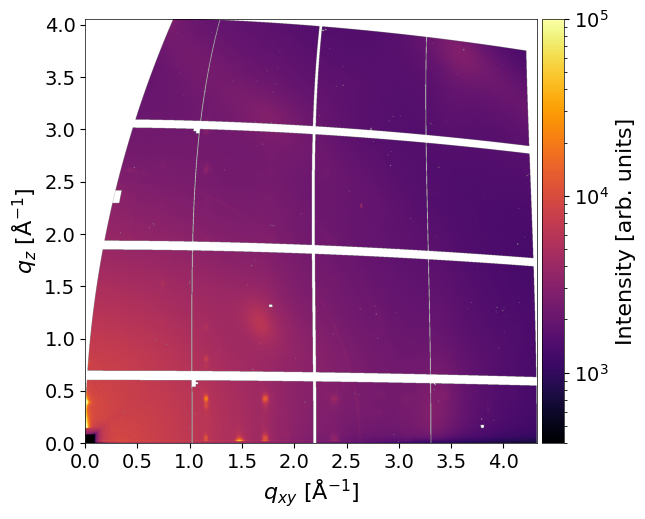

In [14]:
analysis.plot_result(frame_num=0, clims = (4e2,1e5))

- Simulation:

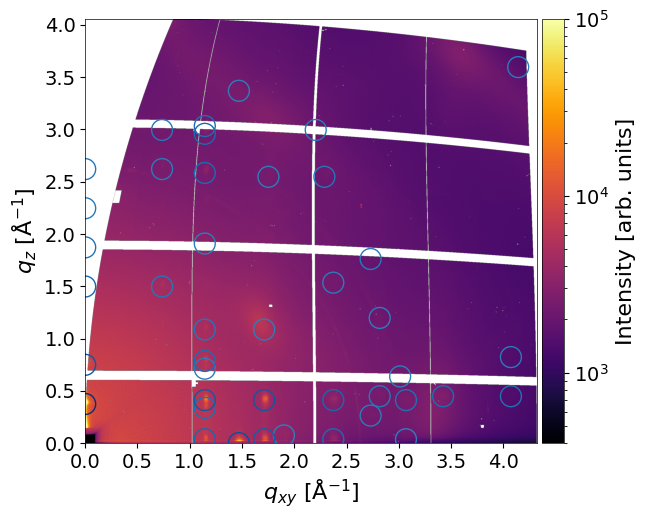

In [15]:
analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    path_to_cif=cif_path,   # Path to crystal structure CIF
    orientation=[0, 0, 1],        # Crystal orientation in lab frame
    min_int=1e-3,                 # Minimal intensity of the peak to show
    plot_result=True,             # Display simulation overlay
    clims=(4e2,1e5),              # Intensity limits
)

- Saving with metadata:

In [16]:
smpl_metadata = nexus.get_smpl_metadata('entry_0000')
exp_metadata = nexus.get_exp_metadata('entry_0000')

pygid.DataSaver(analysis,
                path_to_save='single_entry.h5',
                smpl_metadata=smpl_metadata,
                exp_metadata=exp_metadata)

INFO:DataSaver:Saved in /mnt/Data/Programming/mlgid/pygid/docs/tutorials/single_entry.h5 in group entry_0000
